# Unify All Single‑Drug LD₅₀ Datasets

This notebook integrates multiple single-drug toxicity datasets into a unified, standardized dataset suitable for downstream machine learning and QSAR modeling. The primary objective is to create a clean, non-redundant dataset of molecular structures and their corresponding toxicity values (pLD₅₀).

Key Objectives

- Load and combine multiple LD₅₀ datasets from different sources

- Standardize molecular representations using canonical SMILES

- Ensure consistent formatting of toxicity values (pLD₅₀)

- Identify and resolve duplicate compounds across datasets

- Generate a high-quality unified dataset for model training




In [18]:
from google.colab import drive
drive.mount('/content/drive')

# Install RDKit (required for SMILES canonicalisation)
!pip install rdkit

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


RDKit is used to convert all SMILES to a canonical form, ensuring that the same molecule is represented identically across datasets.

Canonical SMILES is a standardized unique representation of a molecule generated by RDKit so that structurally identical compounds are encoded with exactly the same string regardless of their original notation.

In [19]:
import os

# Base path to your project data folder
base_path = '/content/drive/MyDrive/FYP/IRP/Data'

# Dictionary with dataset name and path to its model‑ready CSV
dataset_paths = {
    'TDC': os.path.join(base_path, 'TD Commons LD50/LD50_Zhu_model_ready.csv'),
    'Hillary': os.path.join(base_path, 'Hillary Mongare LD50 SMILES Dataset/ld50-smiles_model_ready.csv'),
    'TOXRIC': os.path.join(base_path, 'TOXRIC Multiple Endpoint Acute Toxicity (Figshare)/TOXRIC_acute_toxicity_model_ready.csv'),
    'USA data.gov': os.path.join(base_path, 'Acute_Oral_Toxicity/Acute_Oral_Toxicity_model_ready.csv')
}

## Load and Standardise Each Dataset

In [20]:
import pandas as pd
from rdkit import Chem
from rdkit.Chem import MolToSmiles

def canonical_smiles(smiles):
    """Convert SMILES to canonical form; return None if invalid."""
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    return MolToSmiles(mol, canonical=True)

all_dfs = []

for source, path in dataset_paths.items():
    print(f"\nProcessing {source}...")
    df = pd.read_csv(path)

    # --- Map columns to standard names ---
    # Each file may have different column names.
    # Expect two columns: one with SMILES, one with the target (pLD50).
    # The target column may be named differently.
    # First column is SMILES and the second is pLD50.

    if df.shape[1] != 2:
        print(f"Warning: {source} has {df.shape[1]} columns. Please check.")
        continue

    # Rename columns to standard names
    df.columns = ['SMILES', 'pLD50']

    # --- Remove rows with missing values ---
    initial_len = len(df)
    df = df.dropna(subset=['SMILES', 'pLD50'])
    print(f"Dropped {initial_len - len(df)} rows with missing values.")

    # --- Convert pLD50 to numeric ---
    df['pLD50'] = pd.to_numeric(df['pLD50'], errors='coerce')
    df = df.dropna(subset=['pLD50'])

    # --- Canonicalise SMILES ---
    df['SMILES_canon'] = df['SMILES'].apply(canonical_smiles)
    df = df.dropna(subset=['SMILES_canon'])
    print(f"Retained {len(df)} rows with valid canonical SMILES.")

    # --- Add source column ---
    df['source'] = source

    # Keep only needed columns
    df_final = df[['SMILES_canon', 'pLD50', 'source']].rename(columns={'SMILES_canon': 'SMILES'})
    all_dfs.append(df_final)


Processing TDC...
Dropped 0 rows with missing values.
Retained 5138 rows with valid canonical SMILES.

Processing Hillary...
Dropped 0 rows with missing values.
Retained 7341 rows with valid canonical SMILES.

Processing TOXRIC...
Dropped 0 rows with missing values.
Retained 10189 rows with valid canonical SMILES.

Processing USA data.gov...
Dropped 0 rows with missing values.
Retained 6719 rows with valid canonical SMILES.


In [21]:
# Concatenate all dataframes
combined = pd.concat(all_dfs, ignore_index=True)
print(f"\nTotal rows before deduplication: {len(combined)}")


Total rows before deduplication: 29387


In [22]:
combined.sample()

,SMILES,pLD50,source
26733,COP(=O)(OC)OC(=C(Cl)Br)c1ccc(Cl)cc1Cl,3.583839,USA data.gov


In [23]:
# 1. Count total rows and unique SMILES
print(f"Total rows: {len(combined)}")
print(f"Unique SMILES: {combined['SMILES'].nunique()}")

# 2. Identify rows with duplicate SMILES
duplicated_mask = combined.duplicated('SMILES', keep=False)
duplicated_rows = combined[duplicated_mask]

print(f"\nNumber of rows that belong to duplicate groups: {len(duplicated_rows)}")
print(f"Number of unique SMILES that are duplicated: {duplicated_rows['SMILES'].nunique()}")

# 3. Show a few examples of duplicated SMILES
if len(duplicated_rows) > 0:
    print("\nExample duplicated SMILES (showing all occurrences):")
    # Take the first duplicated SMILES group
    example_smiles = duplicated_rows['SMILES'].iloc[0]
    example_group = combined[combined['SMILES'] == example_smiles]
    print(example_group)
else:
    print("\nNo duplicates found. The datasets appear disjoint.")

# 4. break down duplicates by source
if len(duplicated_rows) > 0:
    # Create a cross-tabulation of duplicates
    dup_summary = duplicated_rows.groupby('SMILES')['source'].apply(lambda x: ','.join(sorted(set(x)))).reset_index()
    print("\nSources involved in duplicates:")
    print(dup_summary['source'].value_counts())

Total rows: 29387
Unique SMILES: 13579

Number of rows that belong to duplicate groups: 22993
Number of unique SMILES that are duplicated: 7185

Example duplicated SMILES (showing all occurrences):
                          SMILES     pLD50        source
0      BrC(Br)(Br)c1ccc2ccccc2n1  1.749000           TDC
5140   BrC(Br)(Br)c1ccc2ccccc2n1  1.749000       Hillary
20112  BrC(Br)(Br)c1ccc2ccccc2n1  1.749118        TOXRIC
27460  BrC(Br)(Br)c1ccc2ccccc2n1  1.749118  USA data.gov

Sources involved in duplicates:
source
Hillary,TDC,TOXRIC,USA data.gov    2876
Hillary,TOXRIC,USA data.gov        1242
Hillary,TDC,TOXRIC                 1083
Hillary,TOXRIC                      552
Hillary,TDC                         354
TDC,TOXRIC,USA data.gov             350
TOXRIC,USA data.gov                 320
TDC,TOXRIC                          187
Hillary,TDC,USA data.gov            116
Hillary,USA data.gov                 62
TDC,USA data.gov                     28
USA data.gov                         

In [24]:
combined[combined['SMILES'] == 'O=C(O)C(Cl)(Cl)CCl']

,SMILES,pLD50,source
4398,O=C(O)C(Cl)(Cl)CCl,1.858000,TDC
11430,O=C(O)C(Cl)(Cl)CCl,1.858000,Hillary
19076,O=C(O)C(Cl)(Cl)CCl,1.858053,TOXRIC


## Handle Duplicate SMILES Across Sources

Some molecules may appear in more than one dataset. For each SMILES, we take the median pLD50 across all occurrences. This reduces noise from outlier measurements.

When aggregating duplicate SMILES from multiple sources, the median is chosen over the mean because it is robust to outliers and extreme values. Experimental LD₅₀ measurements can vary due to differences in protocols, laboratories, or biological variability. Using the median ensures that a single aberrant value does not unduly influence the final representative toxicity for a compound. This practice aligns with modern cheminformatics guidelines for data curation, where robust aggregation methods are recommended for consolidating replicate measurements to obtain reliable central tendencies (Fourches et al., 2016; Tropsha et al., 2015). The median provides a stable estimate that better reflects the typical toxicity of a molecule across diverse experimental conditions.

In [25]:
combined_agg = combined.groupby('SMILES').agg({
    'pLD50': 'median',
    'source': lambda x: ','.join(sorted(set(x)))   # keep track of sources
}).reset_index()

print(f"Rows after deduplication: {len(combined_agg)}")

Rows after deduplication: 13579


In [26]:
combined_agg[combined_agg['SMILES'] == 'BrC(Br)(Br)c1ccc2ccccc2n1']

,SMILES,pLD50,source
10,BrC(Br)(Br)c1ccc2ccccc2n1,1.749059,"Hillary,TDC,TOXRIC,USA data.gov"


In [27]:
combined_agg.sample(5)

,SMILES,pLD50,source
7032,CN(Sc1ccc(F)cc1)C(=O)Oc1cccc2c1OC(C)(C)C2,4.142904,"Hillary,TOXRIC,USA data.gov"
432,C=C(OP(=O)(OC)OC)P(=O)(OC)OC,2.957000,"Hillary,TDC,TOXRIC"
5230,CCN(CCCCCCOC(=O)c1ccc(OC)c(OC)c1)C1CCc2cc(OC)c...,2.252435,USA data.gov
6006,CCOP(=S)(Cl)OCC,2.148000,"Hillary,TDC,TOXRIC"
13365,[CH3][Hg+],3.697211,TOXRIC


In [28]:
len(combined_agg['SMILES'].unique())

13579

Final Checks and Save Unified Dataset

In [29]:
# Quick summary statistics
print("\npLD50 distribution:")
print(combined_agg['pLD50'].describe())


pLD50 distribution:
count    13579.000000
mean         2.506117
std          0.901473
min         -0.343000
25%          1.861000
50%          2.362913
75%          2.957000
max          9.541127
Name: pLD50, dtype: float64


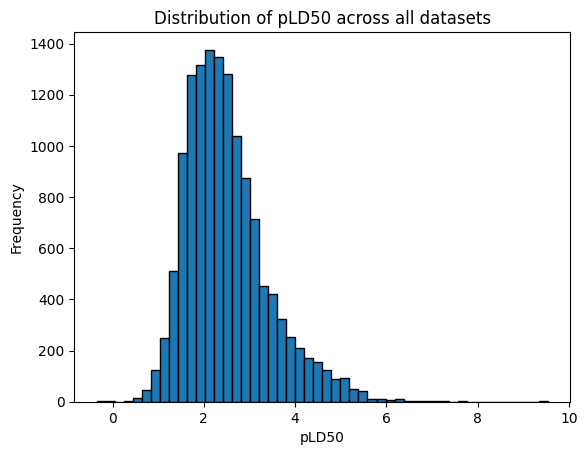

In [30]:
# histogram
import matplotlib.pyplot as plt
plt.hist(combined_agg['pLD50'], bins=50, edgecolor='black')
plt.xlabel('pLD50')
plt.ylabel('Frequency')
plt.title('Distribution of pLD50 across all datasets')
plt.show()

| neglog_molkg range | Interpretation          |
| ------------------ | ----------------------- |
| **< 1.5**          | very low toxicity       |
| **1.5 to 2.0**     | low toxicity            |
| **2.0 to 2.5**     | moderate toxicity       |
| **2.5 to 3.0**     | high toxicity           |
| **3.0 to 3.5**     | very high toxicity      |
| **> 3.5**          | extremely high toxicity |


In [31]:
combined_agg['source'].value_counts()

,count
source,
TOXRIC,3579
"Hillary,TDC,TOXRIC,USA data.gov",2876
USA data.gov,1630
"Hillary,TOXRIC,USA data.gov",1242
"Hillary,TDC,TOXRIC",1083
Hillary,1056
"Hillary,TOXRIC",552
"Hillary,TDC",354
"TDC,TOXRIC,USA data.gov",350


In [32]:
output_path = os.path.join(base_path, 'unified_single_drug_pld50.csv')
combined_agg[['SMILES', 'pLD50','source']].to_csv(output_path, index=False)
print(f"\nUnified dataset saved to: {output_path}")


Unified dataset saved to: /content/drive/MyDrive/FYP/IRP/Data/unified_single_drug_pld50.csv


In [33]:
combined_agg.sample(5)

,SMILES,pLD50,source
13340,S=C=S,1.671432,"TOXRIC,USA data.gov"
11200,NCc1ccccc1,1.974056,TOXRIC
9107,C[CH2][Ge]([CH2]C)([CH2]C)[CH2]C,2.431037,TOXRIC
1153,CC(=O)O.NC1CCCCC1,1.984538,USA data.gov
11254,N[C@@H](Cc1ccc(N(CCCl)CCCl)cc1)C(=O)O,4.435000,Hillary


In [34]:
combined_agg.describe()

,pLD50
count,13579.000000
mean,2.506117
std,0.901473
min,-0.343000
25%,1.861000
50%,2.362913
75%,2.957000
max,9.541127
